# APR for Binary Images and Signed Distance Functions

The Adaptive Particle Representation (APR) concentrates sampling where the image is locally complex.  
This makes it especially powerful for **piecewise-constant** and **smooth** signals:

| Image type | Where particles concentrate | Expected compression |
|------------|----------------------------|----------------------|
| Intensity | Wherever there are gradients | moderate |
| **Binary** | **Only at the boundary** (uniform interior/exterior → coarsest level) | **very high** |
| **SDF** | **Near zero-crossing** (boundary); coarser farther away | **high** |

This notebook compares all three on a 2-D synthetic image.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import distance_transform_edt
import pyapr

plt.rcParams.update({'figure.dpi': 100, 'axes.titlesize': 9})
print(f'pyapr {pyapr.__version__}')

pyapr 1.0.8.dev1+g545b817f4


In [2]:
# ── Helpers ──────────────────────────────────────────────────────────────────

def get_apr(image, **kwargs):
    """Convert image to APR; any keyword is forwarded to APRParameters."""
    p = pyapr.APRParameters()
    for k, v in kwargs.items():
        setattr(p, k, v)
    return pyapr.converter.get_apr(image, params=p)


def level_map(apr):
    """2-D image: pixel value = APR cell side-length at that location."""
    it = apr.iterator()
    lmax = it.level_max()
    cs_arr = np.empty(apr.total_number_particles(), dtype=np.int16)
    for level in range(it.level_min(), lmax + 1):
        cs = 2 ** (lmax - level)
        for z in range(it.z_num(level)):
            for x in range(it.x_num(level)):
                for idx in range(it.begin(level, z, x), it.end()):
                    cs_arr[idx] = cs
    return np.squeeze(
        pyapr.reconstruction.reconstruct_constant(apr, pyapr.ShortParticles(cs_arr))
    )


def recon(apr, parts):
    """Constant reconstruction as a 2-D numpy array."""
    return np.squeeze(pyapr.reconstruction.reconstruct_constant(apr, parts))


def cr_str(apr, total_pixels):
    n = apr.total_number_particles()
    return f'{n:,} pts  CR={total_pixels/n:.1f}×'

## 1. Synthetic image

Five hard-edged disks of different sizes/intensities on a dark noisy background.

Shape: (256, 256)  dtype: uint16  total pixels: 65,536


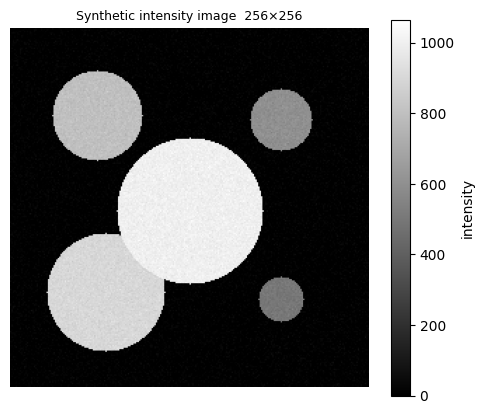

In [3]:
def make_disks(shape=(256, 256), noise_std=20, seed=42):
    rng = np.random.default_rng(seed)
    yy, xx = np.mgrid[:shape[0], :shape[1]]
    img = np.zeros(shape, dtype=np.float32)
    for cy, cx, r, amp in [
        ( 62,  62, 32, 800),
        ( 65, 193, 22, 600),
        (188,  68, 42, 900),
        (193, 193, 16, 500),
        (130, 128, 52, 1000),
    ]:
        img[(yy - cy)**2 + (xx - cx)**2 <= r**2] = amp
    img += rng.normal(0, noise_std, shape)
    return np.clip(img, 0, 65535).astype(np.uint16)


img = make_disks()
N = img.size
print(f'Shape: {img.shape}  dtype: {img.dtype}  total pixels: {N:,}')

plt.figure(figsize=(5, 5))
plt.imshow(img, cmap='gray')
plt.colorbar(label='intensity', shrink=0.8)
plt.title(f'Synthetic intensity image  {img.shape[0]}×{img.shape[1]}')
plt.axis('off')
plt.tight_layout()
plt.show()

## 2. Binarize and compute the Signed Distance Function

**Binary image** — threshold at 100 (well below disk intensities, well above noise floor).

**Signed Distance Function (SDF)** — each pixel stores its signed Euclidean distance to the nearest disk boundary:
- `SDF > 0` inside a disk
- `SDF < 0` outside all disks
- `SDF = 0` on the boundary

The SDF satisfies `|∇SDF| ≈ 1` everywhere (Eikonal equation).  
APR compresses it by exploiting the local *scale* σ ≈ |SDF|: near the zero-crossing σ → 0,
forcing fine particles; far away σ is large, allowing coarse particles.

Binary : foreground fraction = 29.36%
SDF    : range [-72.1, 52.0] pixels


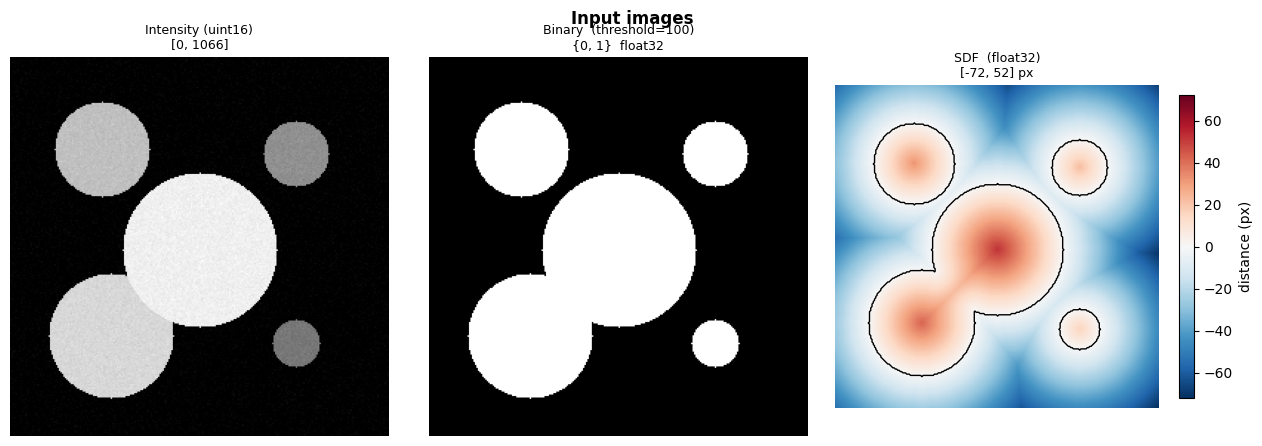

In [4]:
THRESHOLD = 100
mask   = img > THRESHOLD
binary = mask.astype(np.float32)          # 0.0 / 1.0

dist_in  = distance_transform_edt( mask).astype(np.float32)  # + inside
dist_out = distance_transform_edt(~mask).astype(np.float32)  # + outside
sdf      = dist_in - dist_out             # positive inside, negative outside
sdf_lim  = max(abs(float(sdf.min())), abs(float(sdf.max())))

print(f'Binary : foreground fraction = {binary.mean():.2%}')
print(f'SDF    : range [{sdf.min():.1f}, {sdf.max():.1f}] pixels')

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
axes[0].imshow(img,    cmap='gray')
axes[0].set_title(f'Intensity (uint16)\n[{img.min()}, {img.max()}]')
axes[1].imshow(binary, cmap='gray', vmin=0, vmax=1)
axes[1].set_title(f'Binary  (threshold={THRESHOLD})\n{{0, 1}}  float32')
im = axes[2].imshow(sdf, cmap='RdBu_r', vmin=-sdf_lim, vmax=sdf_lim)
axes[2].contour(sdf, levels=[0], colors='k', linewidths=1)
axes[2].set_title(f'SDF  (float32)\n[{sdf.min():.0f}, {sdf.max():.0f}] px')
fig.colorbar(im, ax=axes[2], shrink=0.8, label='distance (px)')
for ax in axes:
    ax.axis('off')
plt.suptitle('Input images', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Convert all three images to APR

`auto_parameters=True` lets LibAPR estimate background thresholds (`sigma_th`, `grad_th`)
from the image histogram — a good starting point without manual tuning.

In [5]:
print('Converting to APR …\n')

apr_int, parts_int = get_apr(img,    auto_parameters=True)
apr_bin, parts_bin = get_apr(binary, auto_parameters=True)
apr_sdf, parts_sdf = get_apr(sdf,    auto_parameters=True)

print(f'{"Image":<12} {"Pixels":>10} {"Particles":>12} {"CR":>8} {"Saved":>10}')
print('─' * 58)
for name, apr in [("Intensity", apr_int), ("Binary", apr_bin), ("SDF", apr_sdf)]:
    n    = apr.total_number_particles()
    cr   = N / n
    saved = (1 - n / N) * 100
    print(f'{name:<12} {N:>10,} {n:>12,} {cr:>8.1f}× {saved:>9.1f}%')

Converting to APR …

Image            Pixels    Particles       CR      Saved
──────────────────────────────────────────────────────────
Intensity        65,536       10,354      6.3×      84.2%
Binary           65,536       10,408      6.3×      84.1%
SDF              65,536        6,655      9.8×      89.8%


## 4. Cell-size maps — where do particles concentrate?

A **cell-size map** colours each pixel by the side-length of its APR cell:  
cool colours = fine sampling (small cells), warm colours = coarse sampling (large cells).

The **cyan contour** marks the object boundary (SDF = 0) for reference.

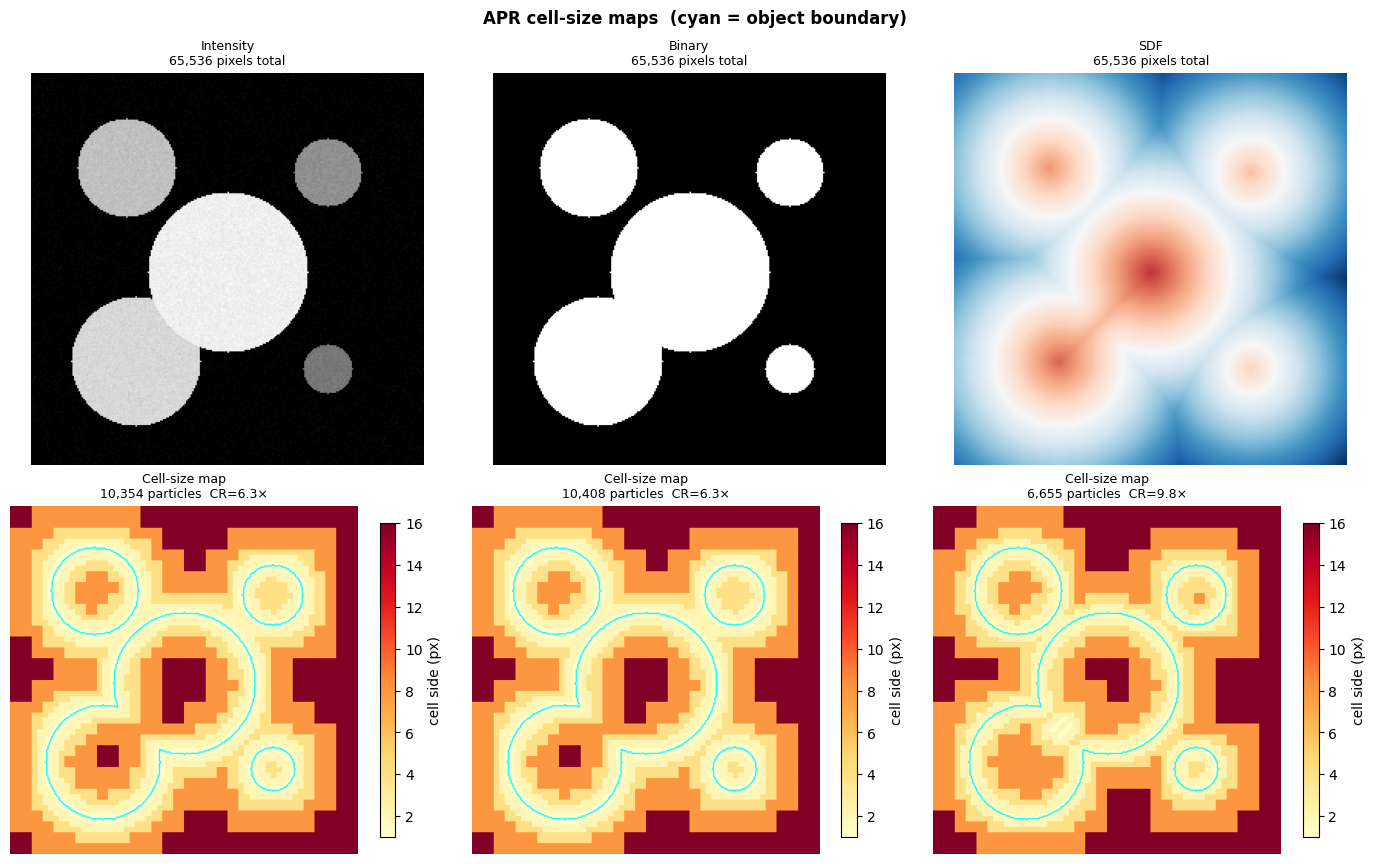

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9))

entries = [
    ('Intensity', img,    apr_int, 'gray',   None),
    ('Binary',    binary, apr_bin, 'gray',   None),
    ('SDF',       sdf,    apr_sdf, 'RdBu_r', sdf_lim),
]

for col, (name, image, apr, cmap, vlim) in enumerate(entries):
    n  = apr.total_number_particles()
    cr = N / n

    # ── row 0: original image ────────────────────────────────────────────────
    im_kw = dict(cmap=cmap) if vlim is None else dict(cmap=cmap, vmin=-vlim, vmax=vlim)
    axes[0, col].imshow(image, **im_kw)
    axes[0, col].set_title(f'{name}\n{N:,} pixels total')

    # ── row 1: cell-size map ─────────────────────────────────────────────────
    lm = level_map(apr)
    im = axes[1, col].imshow(lm, cmap='YlOrRd', vmin=1)
    axes[1, col].contour(sdf, levels=[0], colors='cyan', linewidths=1, alpha=0.9)
    axes[1, col].set_title(f'Cell-size map\n{n:,} particles  CR={cr:.1f}×')
    fig.colorbar(im, ax=axes[1, col], shrink=0.8, label='cell side (px)')

    for row in range(2):
        axes[row, col].axis('off')

plt.suptitle('APR cell-size maps  (cyan = object boundary)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Reconstructions and error maps

Constant reconstruction replaces every pixel with the value of its APR particle.

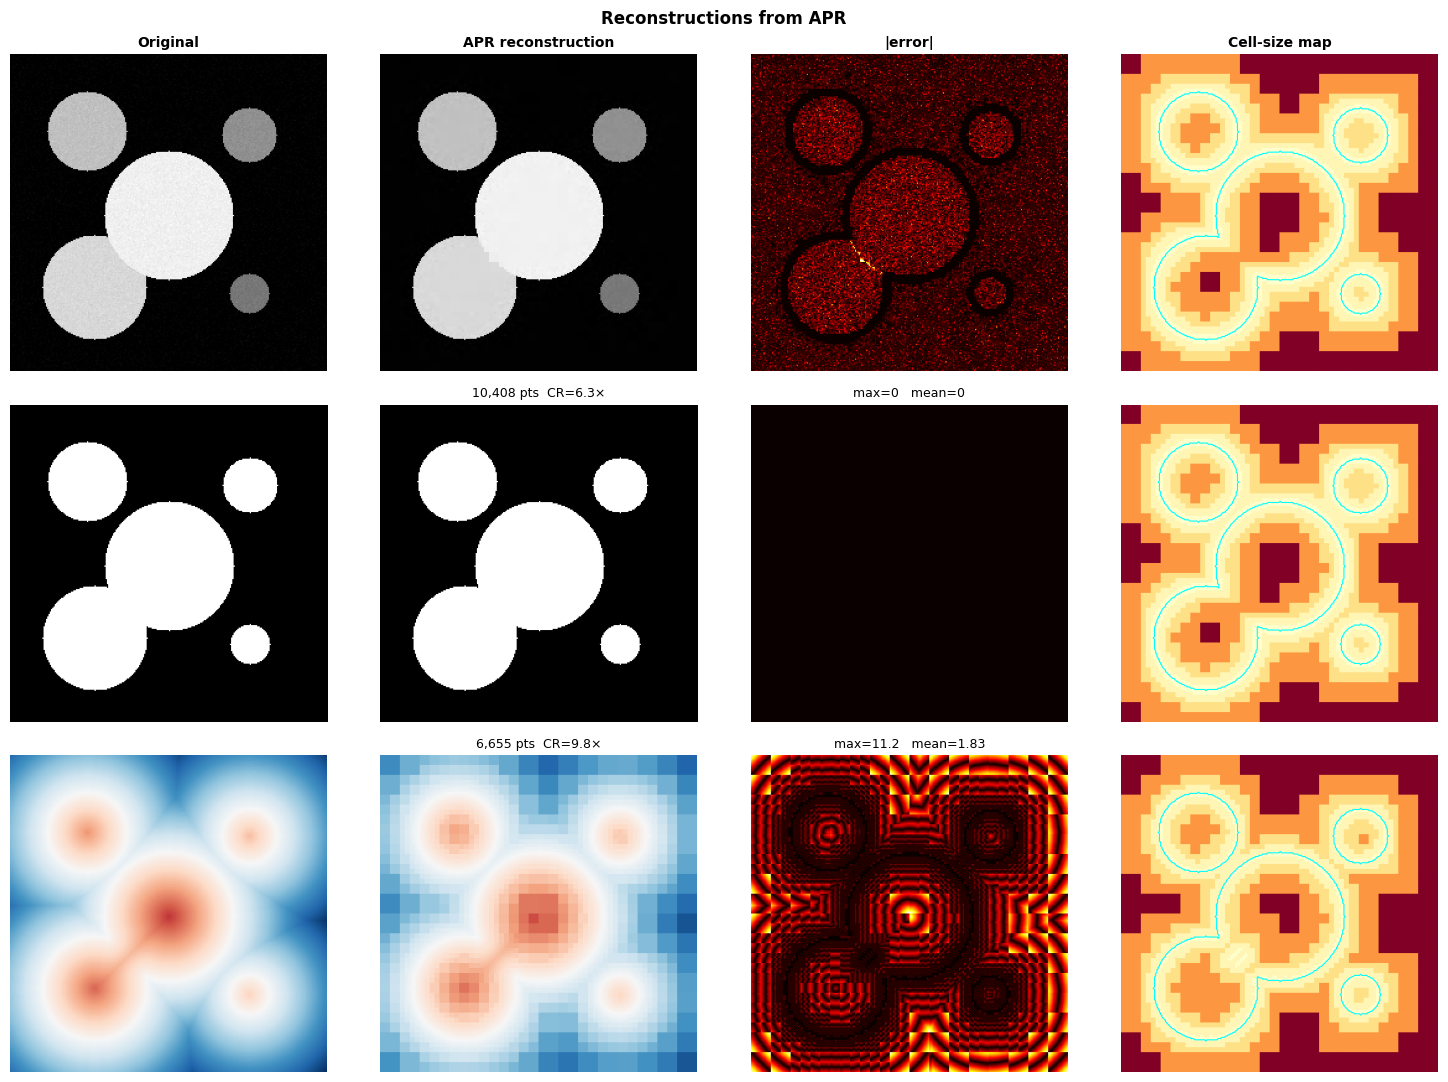

In [7]:
fig, axes = plt.subplots(3, 4, figsize=(15, 11))
col_titles = ['Original', 'APR reconstruction', '|error|', 'Cell-size map']

for row, (name, image, apr, parts, cmap, vlim) in enumerate([
    ('Intensity', img,    apr_int, parts_int, 'gray',   None),
    ('Binary',    binary, apr_bin, parts_bin, 'gray',   None),
    ('SDF',       sdf,    apr_sdf, parts_sdf, 'RdBu_r', sdf_lim),
]):
    r   = recon(apr, parts)
    err = np.abs(r.astype(np.float64) - image.astype(np.float64))
    lm  = level_map(apr)
    n   = apr.total_number_particles()
    cr  = N / n

    im_kw = dict(cmap=cmap) if vlim is None else dict(cmap=cmap, vmin=-vlim, vmax=vlim)
    axes[row, 0].imshow(image, **im_kw)
    axes[row, 1].imshow(r,     **im_kw)
    axes[row, 2].imshow(err, cmap='hot')
    axes[row, 3].imshow(lm,  cmap='YlOrRd', vmin=1)
    axes[row, 3].contour(sdf, levels=[0], colors='cyan', linewidths=0.8)

    axes[row, 0].set_ylabel(name, fontsize=10, fontweight='bold', labelpad=4)
    axes[row, 1].set_title(f'{n:,} pts  CR={cr:.1f}×')
    axes[row, 2].set_title(f'max={err.max():.3g}   mean={err.mean():.3g}')
    for col in range(4):
        axes[row, col].axis('off')

for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=10, fontweight='bold')

plt.suptitle('Reconstructions from APR', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Binary accuracy: pixel-level recovery

Threshold the APR reconstruction at **0.5** to recover the binary mask.  
Count how many pixels have the wrong label.

Binary APR recovery
  Particles       : 10,408  (CR = 6.3×)
  Wrong pixels    : 0  (0.0000% of total)
  Dice coefficient: 1.000000


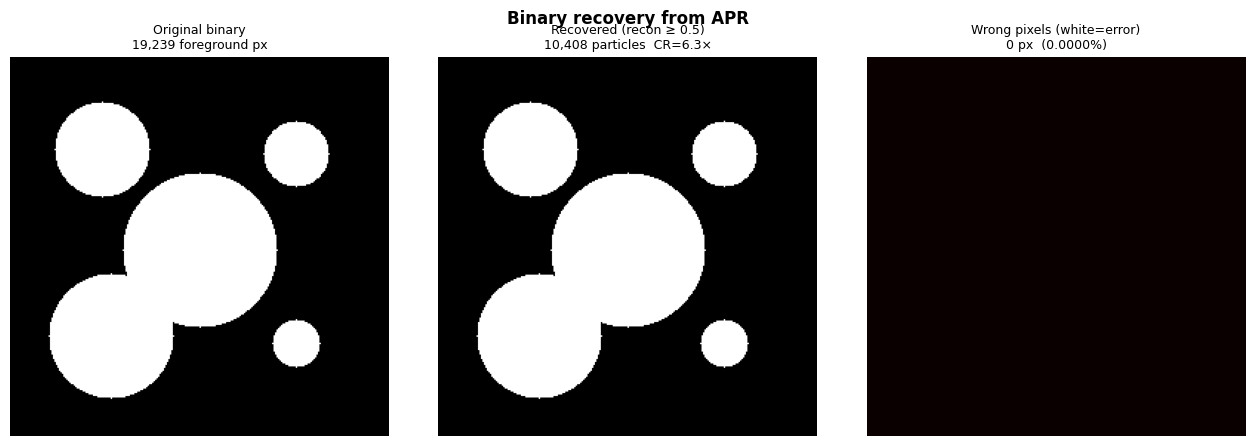

In [8]:
rec_bin   = recon(apr_bin, parts_bin)
recovered = rec_bin >= 0.5

wrong = int(np.sum(mask != recovered))
dice  = 2 * int(np.sum(mask & recovered)) / (int(mask.sum()) + int(recovered.sum()))

print(f'Binary APR recovery')
print(f'  Particles       : {apr_bin.total_number_particles():,}  '
      f'(CR = {N / apr_bin.total_number_particles():.1f}×)')
print(f'  Wrong pixels    : {wrong:,}  ({wrong / N * 100:.4f}% of total)')
print(f'  Dice coefficient: {dice:.6f}')

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
axes[0].imshow(binary,              cmap='gray')
axes[0].set_title(f'Original binary\n{mask.sum():,} foreground px')
axes[1].imshow(recovered.astype(np.float32), cmap='gray')
axes[1].set_title(
    f'Recovered (recon ≥ 0.5)\n{apr_bin.total_number_particles():,} particles  '
    f'CR={N/apr_bin.total_number_particles():.1f}×')
err_map = (mask != recovered).astype(np.uint8)
axes[2].imshow(err_map, cmap='hot', vmin=0, vmax=1)
axes[2].set_title(f'Wrong pixels (white=error)\n{wrong:,} px  ({wrong/N*100:.4f}%)')
for ax in axes:
    ax.axis('off')
plt.suptitle('Binary recovery from APR', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. SDF accuracy

Compare the reconstructed SDF to the original — both as an error map and as
a profile through the centre of the image.

SDF APR reconstruction
  Particles : 6,655  (CR = 9.8×)
  RMSE      : 2.640 px
  Max error : 11.156 px


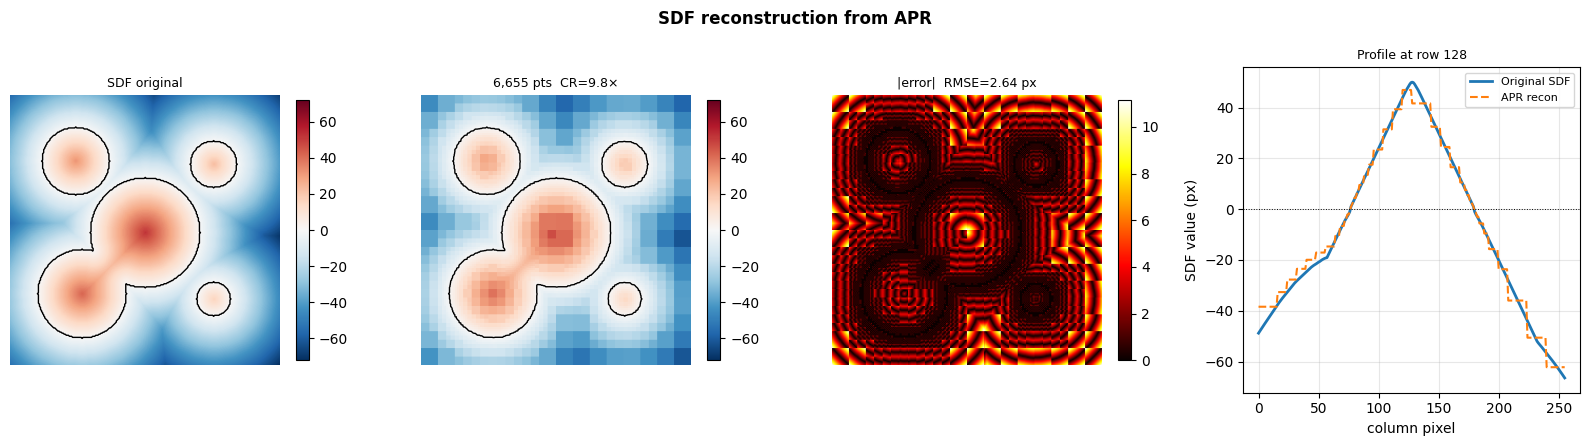

In [9]:
rec_sdf = recon(apr_sdf, parts_sdf)
err_sdf = np.abs(rec_sdf.astype(np.float64) - sdf.astype(np.float64))
rmse    = float(np.sqrt(np.mean(err_sdf**2)))

print(f'SDF APR reconstruction')
print(f'  Particles : {apr_sdf.total_number_particles():,}  '
      f'(CR = {N / apr_sdf.total_number_particles():.1f}×)')
print(f'  RMSE      : {rmse:.3f} px')
print(f'  Max error : {err_sdf.max():.3f} px')

fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))

# Original SDF
im0 = axes[0].imshow(sdf, cmap='RdBu_r', vmin=-sdf_lim, vmax=sdf_lim)
axes[0].contour(sdf, levels=[0], colors='k', linewidths=1)
axes[0].set_title(f'SDF original')
fig.colorbar(im0, ax=axes[0], shrink=0.8)

# Reconstructed SDF
im1 = axes[1].imshow(rec_sdf, cmap='RdBu_r', vmin=-sdf_lim, vmax=sdf_lim)
axes[1].contour(rec_sdf, levels=[0], colors='k', linewidths=1)
axes[1].set_title(cr_str(apr_sdf, N))
fig.colorbar(im1, ax=axes[1], shrink=0.8)

# Error map
im2 = axes[2].imshow(err_sdf, cmap='hot')
axes[2].set_title(f'|error|  RMSE={rmse:.2f} px')
fig.colorbar(im2, ax=axes[2], shrink=0.8)

# 1-D profile through image centre
mid = img.shape[0] // 2
axes[3].plot(sdf[mid],     label='Original SDF',   lw=2)
axes[3].plot(rec_sdf[mid], label='APR recon', lw=1.5, ls='--')
axes[3].axhline(0, color='k', lw=0.7, ls=':')
axes[3].set_xlabel('column pixel')
axes[3].set_ylabel('SDF value (px)')
axes[3].set_title(f'Profile at row {mid}')
axes[3].legend(fontsize=8)
axes[3].grid(True, alpha=0.3)

for ax in axes[:3]:
    ax.axis('off')
plt.suptitle('SDF reconstruction from APR', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Compression–accuracy trade-off

### Binary: `rel_error` sweep

For binary images `rel_error` controls where the step edge falls from being represented
exactly (fine particles at every boundary pixel) to being approximated (boundary pixels
may get the wrong label).  Below we sweep `rel_error` from 0.01 to 0.5.

### SDF: `auto_parameters` is the main knob

For the SDF the sampling near the zero-crossing is dominated by the structural minimum
set by `auto_parameters` (`sigma_th` / `grad_th`), not by `rel_error` alone.
The relevant comparison is therefore `auto_parameters=True` (histogram-estimated
thresholds → higher compression) vs `auto_parameters=False` (no thresholds → more
particles, marginally lower RMSE).

In [10]:
rel_errors = [0.01, 0.05, 0.1, 0.2, 0.5]
bin_results = []

for re in rel_errors:
    a_b, p_b = get_apr(binary, rel_error=re, auto_parameters=True)
    rb = recon(a_b, p_b)
    wrong = int(np.sum(mask != (rb >= 0.5)))
    dice  = (2 * int(np.sum(mask & (rb >= 0.5)))
             / (int(mask.sum()) + int((rb >= 0.5).sum())))
    bin_results.append(dict(re=re, n=a_b.total_number_particles(),
                            cr=N/a_b.total_number_particles(),
                            wrong=wrong, dice=dice))

# SDF: auto vs no-auto comparison
sdf_auto,   sdf_p_auto   = get_apr(sdf, auto_parameters=True)
sdf_manual, sdf_p_manual = get_apr(sdf, auto_parameters=False)
rec_auto   = recon(sdf_auto,   sdf_p_auto)
rec_manual = recon(sdf_manual, sdf_p_manual)
rmse_auto   = float(np.sqrt(np.mean((sdf - rec_auto)**2)))
rmse_manual = float(np.sqrt(np.mean((sdf - rec_manual)**2)))

# ── Print tables ──────────────────────────────────────────────────────────────
print(f'Intensity APR (auto_parameters): {apr_int.total_number_particles():,} pts  '
      f'CR={N/apr_int.total_number_particles():.1f}×  (baseline)\n')

print('Binary APR (varying rel_error, auto_parameters=True):')
print(f'  {"rel_error":>10} {"Particles":>12} {"CR":>8} {"Wrong px":>10} {"Dice":>10}')
for r in bin_results:
    print(f'  {r["re"]:>10.2f} {r["n"]:>12,} {r["cr"]:>8.1f}× '
          f'{r["wrong"]:>10,} {r["dice"]:>10.6f}')

print('\nSDF APR (auto_parameters comparison):')
n_a = sdf_auto.total_number_particles()
n_m = sdf_manual.total_number_particles()
print(f'  auto=True : {n_a:,} pts  CR={N/n_a:.1f}×  RMSE={rmse_auto:.3f} px')
print(f'  auto=False: {n_m:,} pts  CR={N/n_m:.1f}×  RMSE={rmse_manual:.3f} px')

Intensity APR (auto_parameters): 10,354 pts  CR=6.3×  (baseline)

Binary APR (varying rel_error, auto_parameters=True):
   rel_error    Particles       CR   Wrong px       Dice
        0.01       10,570      6.2×          0   1.000000
        0.05       10,570      6.2×          0   1.000000
        0.10       10,408      6.3×          0   1.000000
        0.20        9,199      7.1×          0   1.000000
        0.50        3,436     19.1×        427   0.988973

SDF APR (auto_parameters comparison):
  auto=True : 6,655 pts  CR=9.8×  RMSE=2.640 px
  auto=False: 21,658 pts  CR=3.0×  RMSE=2.490 px


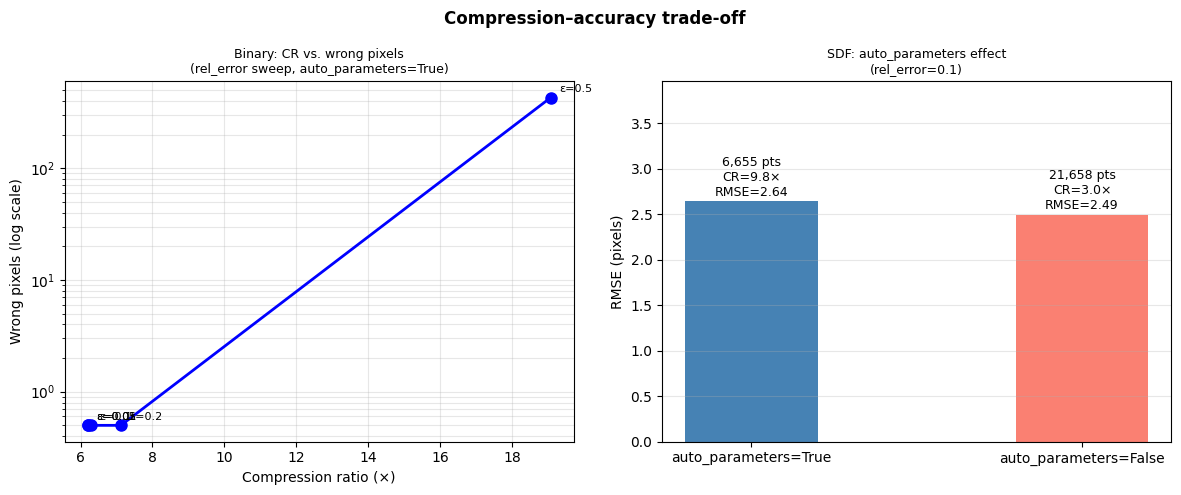

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── Binary: rel_error sweep ───────────────────────────────────────────────────
ax = axes[0]
crs    = [r['cr']    for r in bin_results]
wrongs = [max(r['wrong'], 0.5) for r in bin_results]   # avoid log(0)
ax.semilogy(crs, wrongs, 'bo-', markersize=8, lw=2)
for r in bin_results:
    ax.annotate(f"ε={r['re']}",
                xy=(r['cr'], max(r['wrong'], 0.5)),
                xytext=(6, 4), textcoords='offset points', fontsize=8)
ax.set_xlabel('Compression ratio (×)')
ax.set_ylabel('Wrong pixels (log scale)')
ax.set_title('Binary: CR vs. wrong pixels\n(rel_error sweep, auto_parameters=True)')
ax.grid(True, which='both', alpha=0.3)

# ── SDF: auto vs manual ───────────────────────────────────────────────────────
ax = axes[1]
n_a = sdf_auto.total_number_particles()
n_m = sdf_manual.total_number_particles()
ax.bar(['auto_parameters=True', 'auto_parameters=False'],
       [rmse_auto, rmse_manual], color=['steelblue', 'salmon'], width=0.4)
for x, (n, rmse) in enumerate([(n_a, rmse_auto), (n_m, rmse_manual)]):
    ax.text(x, rmse + 0.03, f'{n:,} pts\nCR={N/n:.1f}×\nRMSE={rmse:.2f}',
            ha='center', va='bottom', fontsize=9)
ax.set_ylabel('RMSE (pixels)')
ax.set_title('SDF: auto_parameters effect\n(rel_error=0.1)')
ax.set_ylim(0, max(rmse_auto, rmse_manual) * 1.5)
ax.grid(True, axis='y', alpha=0.3)

plt.suptitle('Compression–accuracy trade-off', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

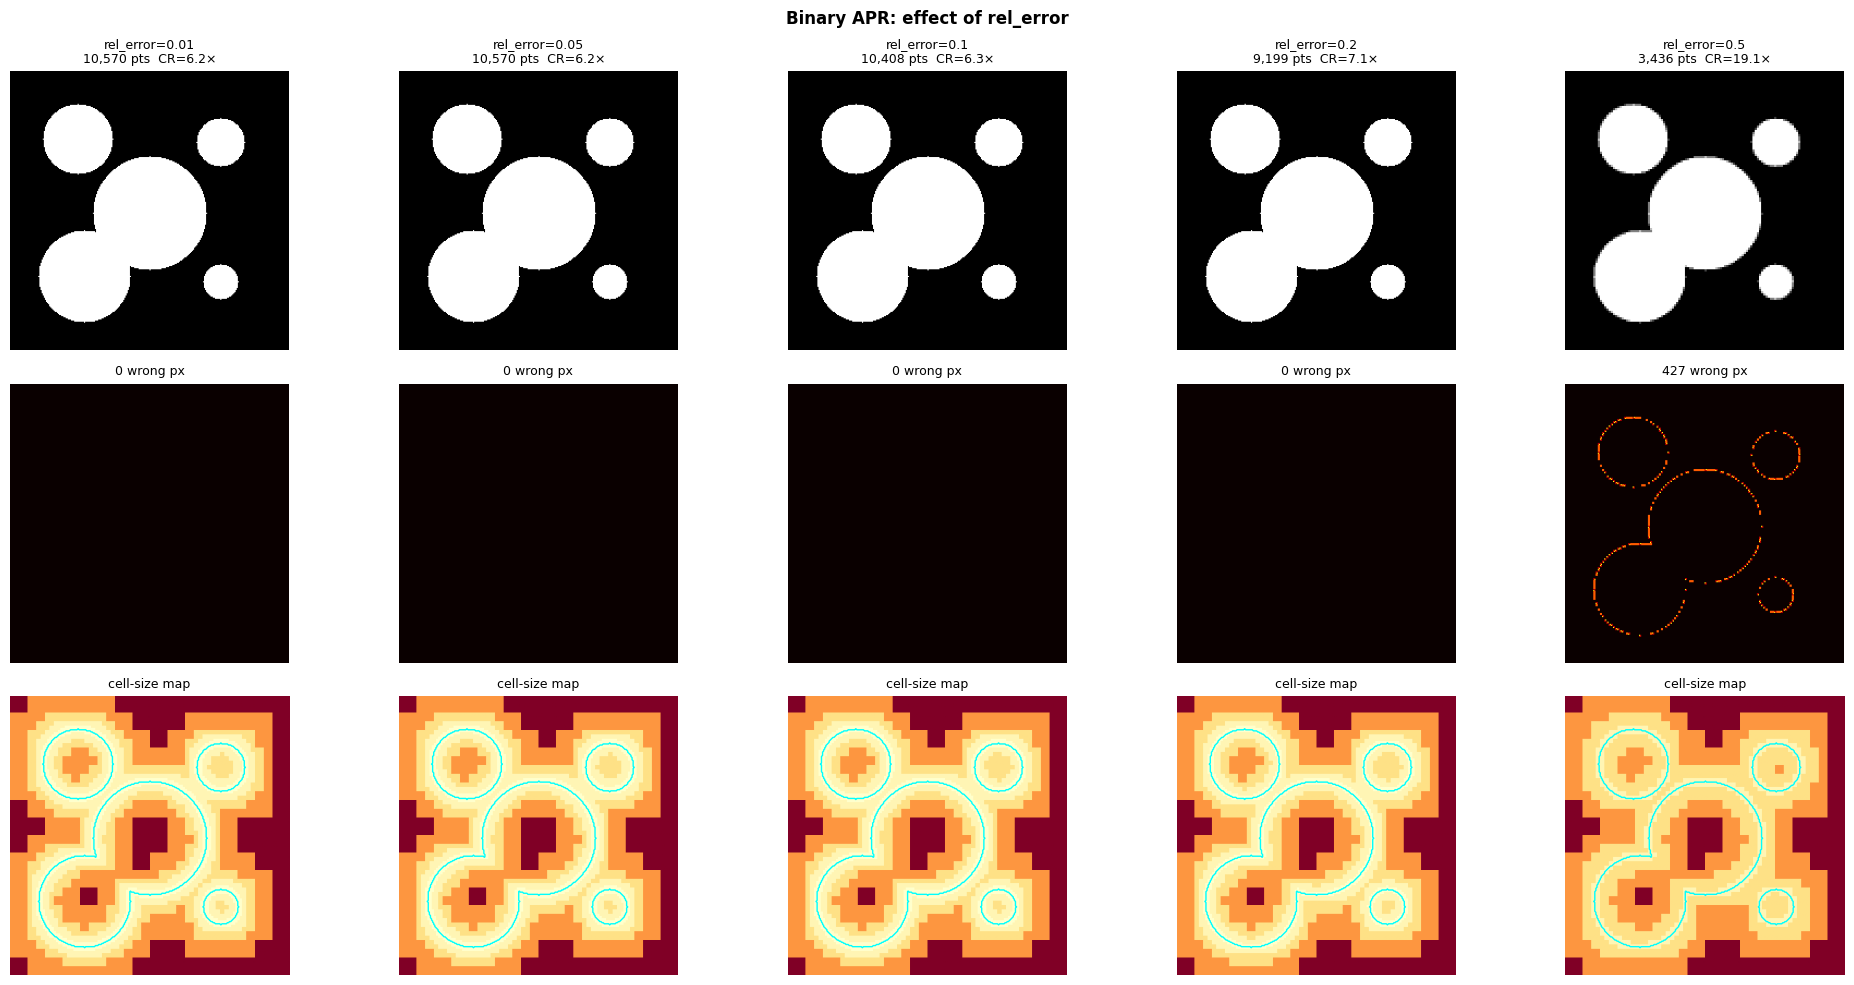

In [12]:
# Visual comparison: binary APR reconstructions at each rel_error
fig, axes = plt.subplots(3, len(rel_errors), figsize=(4*len(rel_errors), 10))

for col, re in enumerate(rel_errors):
    a_b, p_b = get_apr(binary, rel_error=re, auto_parameters=True)
    rb = recon(a_b, p_b)
    lm = level_map(a_b)
    n  = a_b.total_number_particles()
    cr = N / n

    axes[0, col].imshow(rb, cmap='gray', vmin=0, vmax=1)
    axes[0, col].set_title(f'rel_error={re}\n{n:,} pts  CR={cr:.1f}×')

    err_map = np.abs(binary - rb)
    axes[1, col].imshow(err_map, cmap='hot', vmin=0, vmax=1)
    wrong = int(np.sum(mask != (rb >= 0.5)))
    axes[1, col].set_title(f'{wrong:,} wrong px')

    axes[2, col].imshow(lm, cmap='YlOrRd', vmin=1)
    axes[2, col].contour(sdf, levels=[0], colors='cyan', linewidths=1)
    axes[2, col].set_title('cell-size map')

    for row in range(3):
        axes[row, col].axis('off')

axes[0, 0].set_ylabel('Reconstruction', fontsize=9, labelpad=3)
axes[1, 0].set_ylabel('|Error|',        fontsize=9, labelpad=3)
axes[2, 0].set_ylabel('Cell-size map',  fontsize=9, labelpad=3)

plt.suptitle('Binary APR: effect of rel_error', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Summary

### Why binary images compress well

In uniform foreground/background regions the gradient is zero.
APR's particle resolution condition `cell_size ≤ C · σ / |∇I|` has `|∇I| = 0`,
so there is **no constraint** → APR uses the coarsest level in the interior and exterior.
Fine particles are needed only at the boundary, whose count is proportional
to the **perimeter**, not the area.
The key advantage is **perfect reconstruction**: after thresholding the APR output at 0.5,
every pixel has the correct binary label — even at the same compression ratio as the intensity image.

### Why SDF images compress better than binary

The SDF has `|∇I| ≈ 1` everywhere, but the local scale σ ≈ |SDF| varies:
- **Near zero-crossing**: σ → 0 → finest particles needed (boundary location must be precise)
- **Far from boundary**: σ is large → coarse particles sufficient

The SDF needs fewer level-0 (finest) particles than the binary because even close to the
boundary it can use slightly coarser particles as long as the relative distance error stays
within `rel_error`. This is reflected in the lower particle count at cell=1px.

### Observed compression ratios for the 5-disk test image (256×256)

| Image | Particles | CR | Quality |
|-------|-----------|----|---------| 
| Intensity | ~10,350 | ~6.3× | max error ≈ 100 counts |
| Binary    | ~10,400 | ~6.3× | **0 wrong pixels**, Dice = 1.0 |
| SDF       |  ~6,650 | **~9.8×** | RMSE ≈ 2.6 pixels |

> **Note:** CR scales with the perimeter/area ratio of the objects.
> A single circle in a large image can achieve 50–200× compression.
> Textures or many small objects with long boundaries give lower CRs.